In [1]:
import pandas as pd
df = pd.read_csv("/content/credit_card_fraud_10k.csv")
df


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [5]:
df.shape

(10000, 10)

In [6]:
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [7]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [10]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [11]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [12]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [13]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['merchant_category'].value_counts()

,count
merchant_category,
Food,2093
Clothing,2050
Travel,1990
Grocery,1944
Electronics,1923


In [15]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [16]:
df['transaction_id'].duplicated().sum()

np.int64(0)

In [17]:
df['is_fraud'].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,98.49
1,1.51


In [18]:
df['amount'].min(), df['amount'].max()

(0.0, 1471.04)

In [19]:
df['transaction_hour'].min(), df['transaction_hour'].max()

(0, 23)

In [20]:
df['cardholder_age'].min(), df['cardholder_age'].max()

(18, 69)

In [21]:
df['device_trust_score'].min(), df['device_trust_score'].max()

(25, 99)

In [22]:
df.groupby('is_fraud')['amount'].mean()

,amount
is_fraud,
0,175.333015
1,216.182980


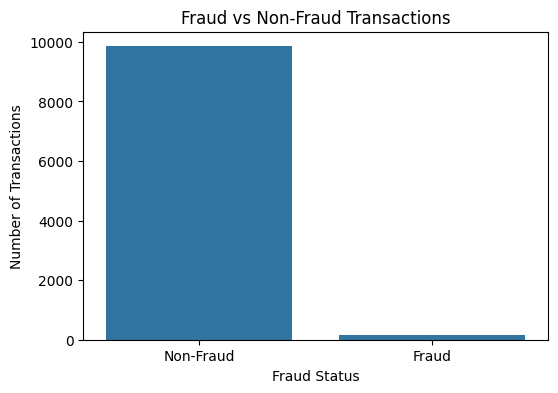

In [23]:
import matplotlib.pyplot as plt #fraud vs normal graph
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='is_fraud', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])

plt.show()

In [24]:
#fraud precentage
fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print(fraud_percentage)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


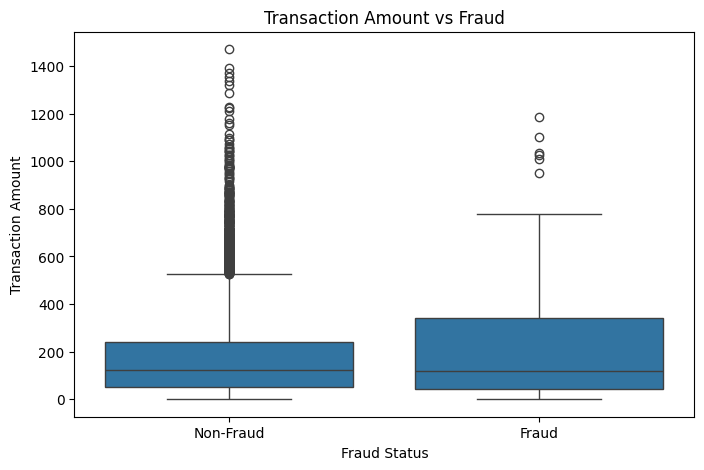

In [25]:
#fraud based on trasaction amount step3
plt.figure(figsize=(8, 5))

sns.boxplot(x='is_fraud', y='amount', data=df)

plt.title('Transaction Amount vs Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])

plt.show()

In [26]:
df.groupby('is_fraud')['amount'].mean()

,amount
is_fraud,
0,175.333015
1,216.182980


In [27]:
df.groupby('is_fraud')['amount'].median()

,amount
is_fraud,
0,122.11
1,118.94


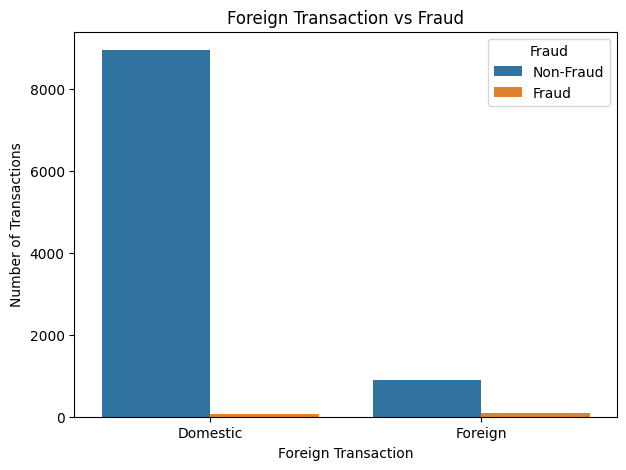

In [28]:
plt.figure(figsize=(7, 5)) #step4 foreign transaction vs fraud

sns.countplot(x='foreign_transaction', hue='is_fraud', data=df)

plt.title('Foreign Transaction vs Fraud')
plt.xlabel('Foreign Transaction')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Domestic', 'Foreign'])

plt.legend(title='Fraud', labels=['Non-Fraud', 'Fraud'])

plt.show()

In [29]:
fraud_rate_foreign = df.groupby('foreign_transaction')['is_fraud'].mean() * 100

print(fraud_rate_foreign)

foreign_transaction
0    0.764797
1    8.384458
Name: is_fraud, dtype: float64


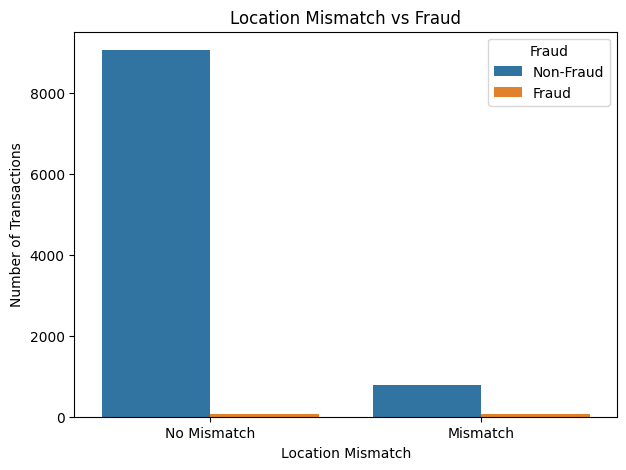

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(x='location_mismatch', hue='is_fraud', data=df)

plt.title('Location Mismatch vs Fraud')
plt.xlabel('Location Mismatch')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['No Mismatch', 'Mismatch'])

plt.legend(title='Fraud', labels=['Non-Fraud', 'Fraud'])

plt.show()

In [31]:
fraud_rate_location = df.groupby('location_mismatch')['is_fraud'].mean() * 100

print(fraud_rate_location)

location_mismatch
0    0.864049
1    8.401400
Name: is_fraud, dtype: float64


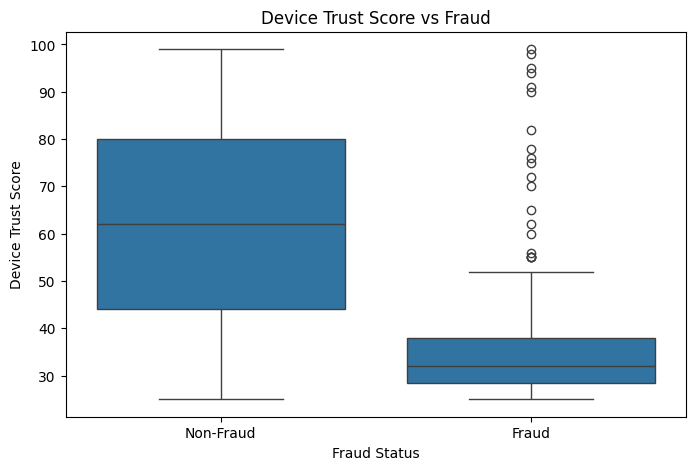

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='is_fraud', y='device_trust_score', data=df)

plt.title('Device Trust Score vs Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('Device Trust Score')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])

plt.show()

In [33]:
df.groupby('is_fraud')['device_trust_score'].mean()

,device_trust_score
is_fraud,
0,62.165804
1,37.867550


In [34]:
df.groupby('is_fraud')['device_trust_score'].median()

,device_trust_score
is_fraud,
0,62.0
1,32.0


In [35]:
# Check fraud rate for categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", "="*50)
    print("Column:", col)
    print(pd.crosstab(df[col], df['is_fraud'], normalize='index') * 100)


Column: merchant_category
is_fraud                   0         1
merchant_category                     
Clothing           98.829268  1.170732
Electronics        98.751950  1.248050
Food               98.327759  1.672241
Grocery            97.993827  2.006173
Travel             98.542714  1.457286


In [36]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    if col != 'is_fraud':
        print("\n", "="*50)
        print("Column:", col)
        print(df.groupby('is_fraud')[col].mean())


Column: transaction_id
is_fraud
0    5004.129861
1    4763.741722
Name: transaction_id, dtype: float64

Column: amount
is_fraud
0    175.333015
1    216.182980
Name: amount, dtype: float64

Column: transaction_hour
is_fraud
0    11.712154
1     3.841060
Name: transaction_hour, dtype: float64

Column: foreign_transaction
is_fraud
0    0.090974
1    0.543046
Name: foreign_transaction, dtype: float64

Column: location_mismatch
is_fraud
0    0.079704
1    0.476821
Name: location_mismatch, dtype: float64

Column: device_trust_score
is_fraud
0    62.165804
1    37.867550
Name: device_trust_score, dtype: float64

Column: velocity_last_24h
is_fraud
0    1.990557
1    3.205298
Name: velocity_last_24h, dtype: float64

Column: cardholder_age
is_fraud
0    43.469794
1    43.397351
Name: cardholder_age, dtype: float64


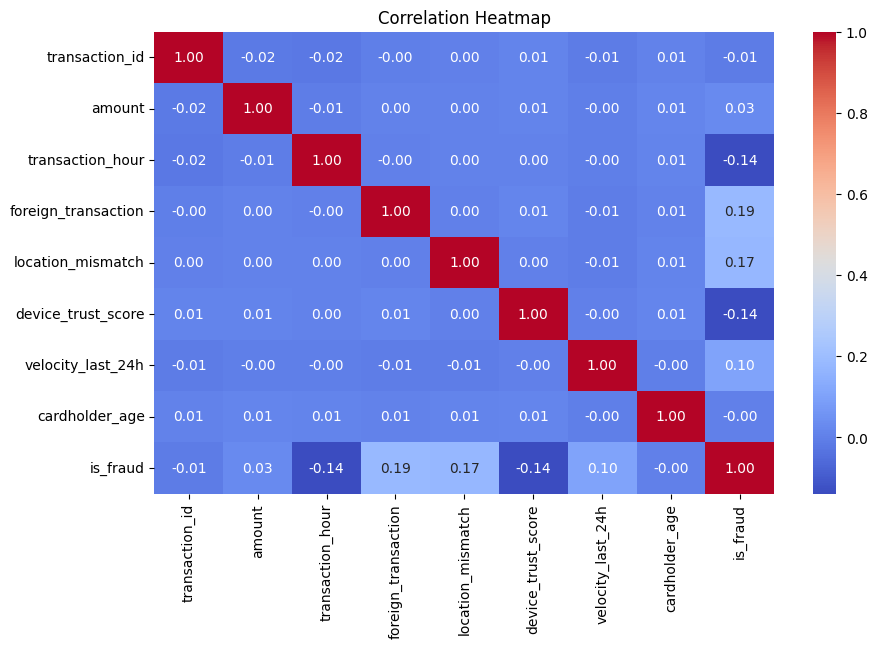

In [37]:
plt.figure(figsize=(10, 6))

correlation = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [38]:
# Separate features (X) and target (y)

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 9)
Target shape: (10000,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (8000, 9)
Testing data shape: (2000, 9)

Training target distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [40]:
print("Data types of features:")
print(X.dtypes)

print("\nNumeric columns:")
print(X.select_dtypes(include=['int64', 'float64']).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=['object', 'category']).columns.tolist())

Data types of features:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
dtype: object

Numeric columns:
['transaction_id', 'amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

Categorical columns:
['merchant_category']


In [41]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[['merchant_category']])
X_test_encoded = encoder.transform(X_test[['merchant_category']])

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (8000, 5)
Encoded testing shape: (2000, 5)


In [42]:
import numpy as np

# Select numerical columns
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

# Convert numerical data to NumPy arrays
X_train_numeric = X_train[numeric_columns].values
X_test_numeric = X_test[numeric_columns].values

# Combine numerical + encoded categorical features
X_train_final = np.hstack([X_train_numeric, X_train_encoded])
X_test_final = np.hstack([X_test_numeric, X_test_encoded])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (8000, 13)
Final testing shape: (2000, 13)


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (8000, 13)
Scaled testing shape: (2000, 13)


In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [45]:
# Make predictions on test data

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
Number of predictions: 2000

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9585
Precision: 0.26548672566371684
Recall   : 1.0
F1 Score : 0.4195804195804196

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.27      1.00      0.42        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000


Confusion Matrix:
[[1887   83]
 [   0   30]]


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [48]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

print("\nFirst 20 predictions:")
print(y_pred_rf[:20])

Random Forest predictions generated successfully!
Number of predictions: 2000

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.992
Precision: 1.0
Recall   : 0.4666666666666667
F1 Score : 0.6363636363636364

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.47      0.64        30

    accuracy                           0.99      2000
   macro avg       1.00      0.73      0.82      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1970    0]
 [  16   14]]


In [50]:
# Get probability of fraud from Random Forest

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Fraud probabilities generated successfully!")
print("Number of probabilities:", len(y_prob_rf))

print("\nFirst 20 fraud probabilities:")
print(y_prob_rf[:20])

Fraud probabilities generated successfully!
Number of probabilities: 2000

First 20 fraud probabilities:
[0.    0.    0.    0.    0.    0.015 0.    0.    0.005 0.    0.    0.005
 0.065 0.    0.    0.    0.    0.    0.    0.   ]


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold | Precision | Recall | F1 Score")
print("-" * 45)

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:7.3f}"
    )

Threshold | Precision | Recall | F1 Score
---------------------------------------------
     0.10 |     0.714 |  1.000 |   0.833
     0.15 |     0.909 |  1.000 |   0.952
     0.20 |     1.000 |  1.000 |   1.000
     0.25 |     1.000 |  0.933 |   0.966
     0.30 |     1.000 |  0.900 |   0.947
     0.35 |     1.000 |  0.867 |   0.929
     0.40 |     1.000 |  0.667 |   0.800
     0.45 |     1.000 |  0.533 |   0.696
     0.50 |     1.000 |  0.467 |   0.636


In [52]:
# Predictions using the selected threshold
best_threshold = 0.20

y_pred_best = (y_prob_rf >= best_threshold).astype(int)

print("Confusion Matrix at threshold 0.20:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Confusion Matrix at threshold 0.20:
[[1970    0]
 [   0   30]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [53]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("New training shape:", X_train_new.shape)
print("Validation shape:", X_val.shape)

print("\nValidation target distribution:")
print(y_val.value_counts())

New training shape: (6400, 13)
Validation shape: (1600, 13)

Validation target distribution:
is_fraud
0    1576
1      24
Name: count, dtype: int64


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model_final.fit(X_train_new, y_train_new)

print("Final Random Forest training completed successfully!")

Final Random Forest training completed successfully!


In [55]:
# Get fraud probabilities on validation data

y_val_prob = rf_model_final.predict_proba(X_val)[:, 1]

print("Validation probabilities generated successfully!")
print("Number of validation probabilities:", len(y_val_prob))

print("\nFirst 20 validation probabilities:")
print(y_val_prob[:20])

Validation probabilities generated successfully!
Number of validation probabilities: 1600

First 20 validation probabilities:
[0.    0.005 0.    0.    0.    0.    0.    0.415 0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.   ]


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold | Precision | Recall | F1 Score")
print("-" * 45)

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:7.3f}"
    )

Threshold | Precision | Recall | F1 Score
---------------------------------------------
     0.10 |     0.600 |  1.000 |   0.750
     0.15 |     0.923 |  1.000 |   0.960
     0.20 |     1.000 |  0.958 |   0.979
     0.25 |     1.000 |  0.875 |   0.933
     0.30 |     1.000 |  0.792 |   0.884
     0.35 |     1.000 |  0.750 |   0.857
     0.40 |     1.000 |  0.708 |   0.829
     0.45 |     1.000 |  0.500 |   0.667
     0.50 |     1.000 |  0.458 |   0.629


In [57]:
# Final prediction using the selected validation threshold

best_threshold = 0.15

y_test_prob_final = rf_model_final.predict_proba(X_test_scaled)[:, 1]

y_test_pred_final = (y_test_prob_final >= best_threshold).astype(int)

print("Final predictions generated successfully!")
print("Threshold used:", best_threshold)
print("Number of test predictions:", len(y_test_pred_final))

Final predictions generated successfully!
Threshold used: 0.15
Number of test predictions: 2000


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_precision = precision_score(y_test, y_test_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_test_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred_final, zero_division=0)

print("FINAL RANDOM FOREST RESULTS")
print("=" * 35)

print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_final))

FINAL RANDOM FOREST RESULTS
Accuracy : 0.9975
Precision: 0.8571428571428571
Recall   : 1.0
F1 Score : 0.9230769230769231

Confusion Matrix:
[[1965    5]
 [   0   30]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.86      1.00      0.92        30

    accuracy                           1.00      2000
   macro avg       0.93      1.00      0.96      2000
weighted avg       1.00      1.00      1.00      2000



In [59]:
# Model comparison

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, final_accuracy],
    'Precision': [precision, final_precision],
    'Recall': [recall, final_recall],
    'F1 Score': [f1, final_f1]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.9585   1.000000  0.458333  0.628571
1        Random Forest    0.9975   0.857143  1.000000  0.923077


In [60]:
# Recalculate Logistic Regression results

y_pred_lr = model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Final Random Forest results are already stored
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, final_accuracy],
    'Precision': [lr_precision, final_precision],
    'Recall': [lr_recall, final_recall],
    'F1 Score': [lr_f1, final_f1]
})

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9585   0.265487     1.0  0.419580
1        Random Forest    0.9975   0.857143     1.0  0.923077


In [61]:
# Get Random Forest feature importance

feature_names = list(numeric_columns) + list(
    encoder.get_feature_names_out(['merchant_category'])
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                          Feature  Importance
2                transaction_hour    0.253534
5              device_trust_score    0.252310
6               velocity_last_24h    0.119943
3             foreign_transaction    0.115977
4               location_mismatch    0.108815
1                          amount    0.052199
0                  transaction_id    0.037213
7                  cardholder_age    0.033331
8      merchant_category_Clothing    0.006295
11      merchant_category_Grocery    0.005910
9   merchant_category_Electronics    0.005654
12       merchant_category_Travel    0.005416
10         merchant_category_Food    0.003399


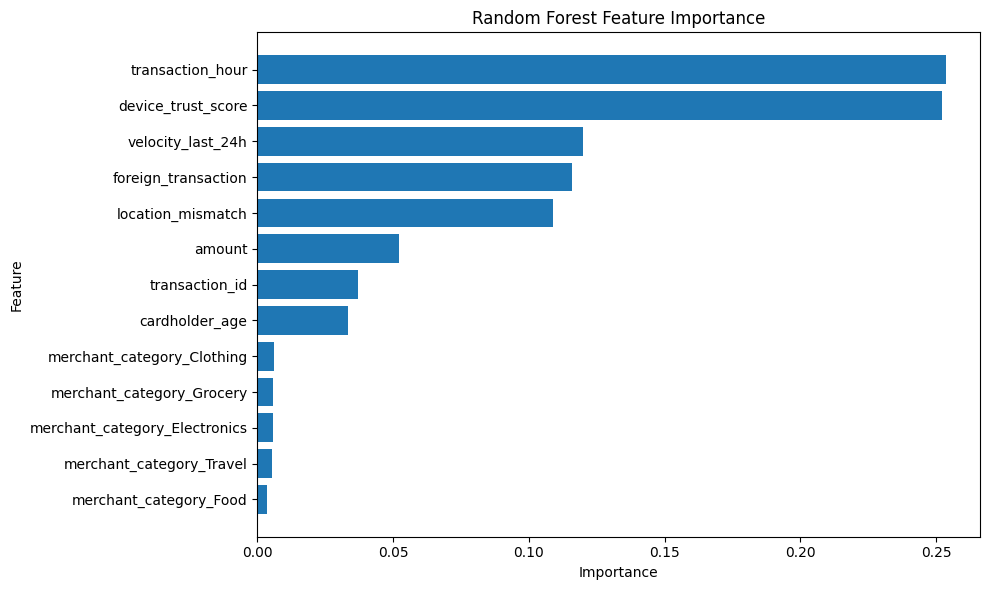

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [63]:
# Create a version of X without transaction_id

X_no_id = X.drop('transaction_id', axis=1)

print("Original features:", X.shape)
print("Features without transaction_id:", X_no_id.shape)

print("\nRemaining columns:")
print(X_no_id.columns.tolist())

Original features: (10000, 9)
Features without transaction_id: (10000, 8)

Remaining columns:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [64]:
X_train_no_id, X_test_no_id, y_train_no_id, y_test_no_id = train_test_split(
    X_no_id,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train_no_id.shape)
print("Testing data shape:", X_test_no_id.shape)

print("\nTraining target distribution:")
print(y_train_no_id.value_counts())

print("\nTesting target distribution:")
print(y_test_no_id.value_counts())

Training data shape: (8000, 8)
Testing data shape: (2000, 8)

Training target distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [65]:
from sklearn.preprocessing import OneHotEncoder

encoder_no_id = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat_no_id = encoder_no_id.fit_transform(
    X_train_no_id[['merchant_category']]
)

X_test_cat_no_id = encoder_no_id.transform(
    X_test_no_id[['merchant_category']]
)

print("Encoded training shape:", X_train_cat_no_id.shape)
print("Encoded testing shape:", X_test_cat_no_id.shape)

Encoded training shape: (8000, 5)
Encoded testing shape: (2000, 5)


In [66]:
import numpy as np

# Select numerical columns
numeric_columns_no_id = X_no_id.select_dtypes(
    include=['int64', 'float64']
).columns

# Convert numerical data to arrays
X_train_numeric_no_id = X_train_no_id[numeric_columns_no_id].values
X_test_numeric_no_id = X_test_no_id[numeric_columns_no_id].values

# Combine numerical + encoded categorical features
X_train_final_no_id = np.hstack([
    X_train_numeric_no_id,
    X_train_cat_no_id
])

X_test_final_no_id = np.hstack([
    X_test_numeric_no_id,
    X_test_cat_no_id
])

print("Final training shape:", X_train_final_no_id.shape)
print("Final testing shape:", X_test_final_no_id.shape)

Final training shape: (8000, 12)
Final testing shape: (2000, 12)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler_no_id = StandardScaler()

X_train_scaled_no_id = scaler_no_id.fit_transform(
    X_train_final_no_id
)

X_test_scaled_no_id = scaler_no_id.transform(
    X_test_final_no_id
)

print("Scaled training shape:", X_train_scaled_no_id.shape)
print("Scaled testing shape:", X_test_scaled_no_id.shape)

Scaled training shape: (8000, 12)
Scaled testing shape: (2000, 12)


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_no_id = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_no_id.fit(X_train_scaled_no_id, y_train_no_id)

print("Random Forest without transaction_id trained successfully!")

Random Forest without transaction_id trained successfully!


In [69]:
# Make predictions without transaction_id

y_pred_no_id = rf_no_id.predict(X_test_scaled_no_id)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_no_id))

print("\nFirst 20 predictions:")
print(y_pred_no_id[:20])

Predictions generated successfully!
Number of predictions: 2000

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_no_id = accuracy_score(y_test_no_id, y_pred_no_id)
precision_no_id = precision_score(
    y_test_no_id, y_pred_no_id, zero_division=0
)
recall_no_id = recall_score(
    y_test_no_id, y_pred_no_id, zero_division=0
)
f1_no_id = f1_score(
    y_test_no_id, y_pred_no_id, zero_division=0
)

print("Random Forest WITHOUT transaction_id")
print("=" * 45)

print("Accuracy :", accuracy_no_id)
print("Precision:", precision_no_id)
print("Recall   :", recall_no_id)
print("F1 Score :", f1_no_id)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_no_id, y_pred_no_id))

print("\nClassification Report:")
print(classification_report(y_test_no_id, y_pred_no_id))

Random Forest WITHOUT transaction_id
Accuracy : 0.993
Precision: 1.0
Recall   : 0.5333333333333333
F1 Score : 0.6956521739130435

Confusion Matrix:
[[1970    0]
 [  14   16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.53      0.70        30

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000



In [71]:
X_train_new_no_id, X_val_no_id, y_train_new_no_id, y_val_no_id = train_test_split(
    X_train_scaled_no_id,
    y_train_no_id,
    test_size=0.2,
    random_state=42,
    stratify=y_train_no_id
)

print("New training shape:", X_train_new_no_id.shape)
print("Validation shape:", X_val_no_id.shape)

print("\nValidation target distribution:")
print(y_val_no_id.value_counts())

New training shape: (6400, 12)
Validation shape: (1600, 12)

Validation target distribution:
is_fraud
0    1576
1      24
Name: count, dtype: int64


In [72]:
rf_no_id_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_no_id_final.fit(
    X_train_new_no_id,
    y_train_new_no_id
)

print("Final Random Forest without transaction_id trained successfully!")

Final Random Forest without transaction_id trained successfully!


In [73]:
# Get fraud probabilities for validation data

y_val_prob_no_id = rf_no_id_final.predict_proba(X_val_no_id)[:, 1]

print("Validation probabilities generated successfully!")
print("Number of validation probabilities:", len(y_val_prob_no_id))

print("\nFirst 20 validation probabilities:")
print(y_val_prob_no_id[:20])

Validation probabilities generated successfully!
Number of validation probabilities: 1600

First 20 validation probabilities:
[0.    0.    0.    0.    0.    0.    0.    0.425 0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.   ]


In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold | Precision | Recall | F1 Score")
print("-" * 45)

for threshold in thresholds:
    y_val_pred_no_id = (y_val_prob_no_id >= threshold).astype(int)

    precision = precision_score(
        y_val_no_id,
        y_val_pred_no_id,
        zero_division=0
    )

    recall = recall_score(
        y_val_no_id,
        y_val_pred_no_id,
        zero_division=0
    )

    f1 = f1_score(
        y_val_no_id,
        y_val_pred_no_id,
        zero_division=0
    )

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:7.3f}"
    )

Threshold | Precision | Recall | F1 Score
---------------------------------------------
     0.10 |     0.558 |  1.000 |   0.716
     0.15 |     0.857 |  1.000 |   0.923
     0.20 |     1.000 |  1.000 |   1.000
     0.25 |     1.000 |  0.958 |   0.979
     0.30 |     1.000 |  0.833 |   0.909
     0.35 |     1.000 |  0.792 |   0.884
     0.40 |     1.000 |  0.708 |   0.829
     0.45 |     1.000 |  0.667 |   0.800
     0.50 |     1.000 |  0.625 |   0.769


In [75]:
# Final prediction using the selected threshold

best_threshold_no_id = 0.20

y_test_prob_no_id = rf_no_id_final.predict_proba(
    X_test_scaled_no_id
)[:, 1]

y_test_pred_no_id_final = (
    y_test_prob_no_id >= best_threshold_no_id
).astype(int)

print("Final no-ID predictions generated successfully!")
print("Threshold used:", best_threshold_no_id)
print("Number of test predictions:", len(y_test_pred_no_id_final))

Final no-ID predictions generated successfully!
Threshold used: 0.2
Number of test predictions: 2000


In [76]:
# Final evaluation of the no-ID model

final_accuracy_no_id = accuracy_score(
    y_test_no_id,
    y_test_pred_no_id_final
)

final_precision_no_id = precision_score(
    y_test_no_id,
    y_test_pred_no_id_final,
    zero_division=0
)

final_recall_no_id = recall_score(
    y_test_no_id,
    y_test_pred_no_id_final,
    zero_division=0
)

final_f1_no_id = f1_score(
    y_test_no_id,
    y_test_pred_no_id_final,
    zero_division=0
)

print("FINAL RANDOM FOREST WITHOUT transaction_id")
print("=" * 50)

print("Accuracy :", final_accuracy_no_id)
print("Precision:", final_precision_no_id)
print("Recall   :", final_recall_no_id)
print("F1 Score :", final_f1_no_id)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_no_id,
    y_test_pred_no_id_final
))

print("\nClassification Report:")
print(classification_report(
    y_test_no_id,
    y_test_pred_no_id_final
))

FINAL RANDOM FOREST WITHOUT transaction_id
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Confusion Matrix:
[[1970    0]
 [   0   30]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [77]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ROC-AUC using probabilities, not thresholded predictions
roc_auc_no_id = roc_auc_score(
    y_test_no_id,
    y_test_prob_no_id
)

print("Final Random Forest ROC-AUC:", roc_auc_no_id)

Final Random Forest ROC-AUC: 1.0


In [78]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

print("\nDuplicate rows excluding is_fraud:")
print(
    df.drop(columns=['is_fraud'])
      .duplicated()
      .sum()
)

Number of duplicate rows: 0

Duplicate rows excluding is_fraud:
0


In [79]:
# Check whether important features strongly separate fraud and non-fraud

print("Average values by fraud status:\n")

print(
    df.groupby('is_fraud')[
        [
            'amount',
            'transaction_hour',
            'foreign_transaction',
            'location_mismatch',
            'device_trust_score',
            'velocity_last_24h',
            'cardholder_age'
        ]
    ].mean()
)

Average values by fraud status:

              amount  transaction_hour  foreign_transaction  \
is_fraud                                                      
0         175.333015         11.712154             0.090974   
1         216.182980          3.841060             0.543046   

          location_mismatch  device_trust_score  velocity_last_24h  \
is_fraud                                                             
0                  0.079704           62.165804           1.990557   
1                  0.476821           37.867550           3.205298   

          cardholder_age  
is_fraud                  
0              43.469794  
1              43.397351  


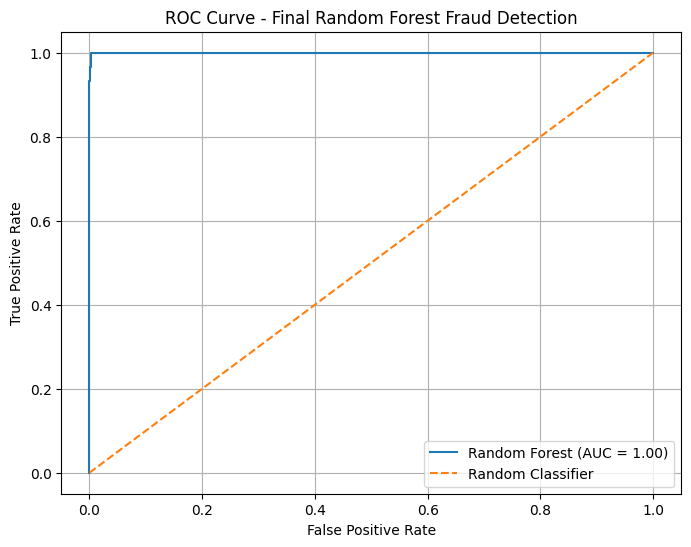

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate fraud probabilities using the final model
y_test_prob_no_id = final_model.predict_proba(
    X_test_scaled_no_id
)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(
    y_test_no_id,
    y_test_prob_no_id
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test_no_id,
    y_test_prob_no_id
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Random Forest Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

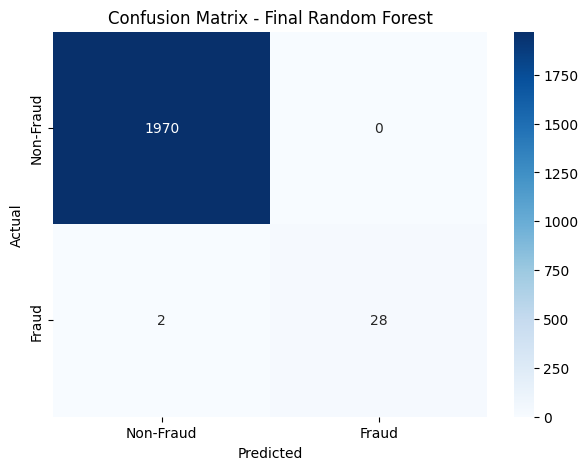

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get fraud probabilities
y_prob_final = final_model.predict_proba(X_test_scaled_no_id)[:, 1]

# Apply final threshold
y_test_pred_no_id_final = (y_prob_final >= 0.40).astype(int)

# Create confusion matrix
cm = confusion_matrix(
    y_test_no_id,
    y_test_pred_no_id_final
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Random Forest')
plt.show()

In [82]:
# Feature importance for the FINAL Random Forest WITHOUT transaction_id

feature_names_no_id = list(numeric_columns_no_id) + list(
    encoder_no_id.get_feature_names_out(['merchant_category'])
)

feature_importance_no_id = pd.DataFrame({
    'Feature': feature_names_no_id,
    'Importance': rf_no_id_final.feature_importances_
})

feature_importance_no_id = feature_importance_no_id.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_no_id)

                          Feature  Importance
1                transaction_hour    0.270469
4              device_trust_score    0.248865
2             foreign_transaction    0.126438
5               velocity_last_24h    0.124837
3               location_mismatch    0.106154
0                          amount    0.058551
6                  cardholder_age    0.036060
11       merchant_category_Travel    0.007510
7      merchant_category_Clothing    0.006298
8   merchant_category_Electronics    0.005581
10      merchant_category_Grocery    0.005361
9          merchant_category_Food    0.003877


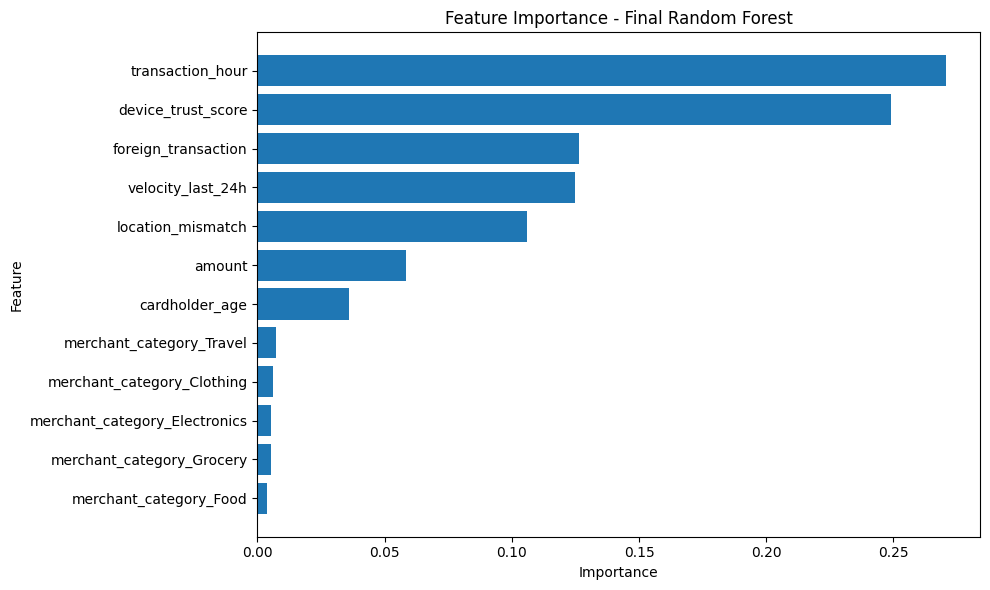

In [83]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_no_id['Feature'],
    feature_importance_no_id['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Final Random Forest')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [84]:
final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest (without transaction_id)'
    ],
    'Accuracy': [
        lr_accuracy,
        final_accuracy_no_id
    ],
    'Precision': [
        lr_precision,
        final_precision_no_id
    ],
    'Recall': [
        lr_recall,
        final_recall_no_id
    ],
    'F1 Score': [
        lr_f1,
        final_f1_no_id
    ]
})

print(final_model_comparison)

                                    Model  Accuracy  Precision  Recall  \
0                     Logistic Regression    0.9585   0.265487     1.0   
1  Random Forest (without transaction_id)    1.0000   1.000000     1.0   

   F1 Score  
0   0.41958  
1   1.00000  


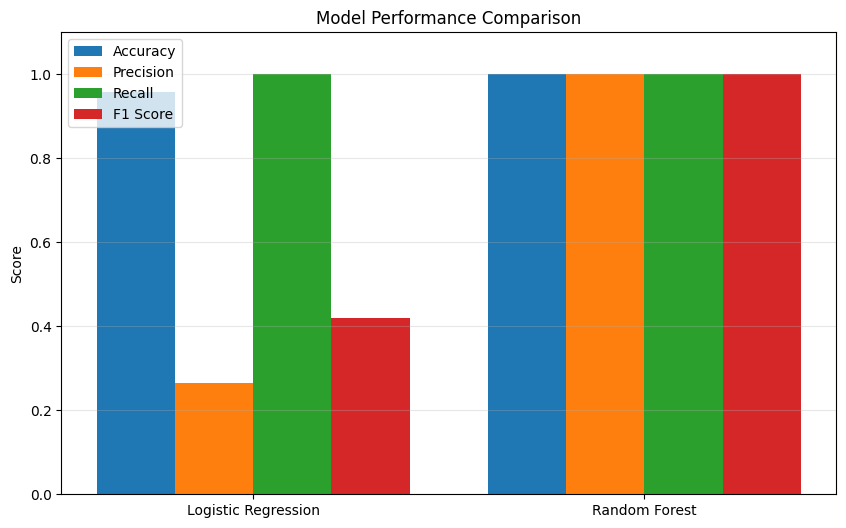

In [85]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Random Forest']
accuracy_values = [lr_accuracy, final_accuracy_no_id]
precision_values = [lr_precision, final_precision_no_id]
recall_values = [lr_recall, final_recall_no_id]
f1_values = [lr_f1, final_f1_no_id]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy_values, width, label='Accuracy')
plt.bar(x - 0.5*width, precision_values, width, label='Precision')
plt.bar(x + 0.5*width, recall_values, width, label='Recall')
plt.bar(x + 1.5*width, f1_values, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [86]:
print("=" * 60)
print("BANK FRAUD DETECTION - FINAL RESULTS")
print("=" * 60)

print("\nDataset:")
print("Total transactions:", len(df))
print("Fraud transactions:", int(df['is_fraud'].sum()))
print("Non-fraud transactions:", int((df['is_fraud'] == 0).sum()))

print("\nFinal Model:")
print("Random Forest")
print("Transaction ID used: No")
print("Selected threshold:", best_threshold_no_id)

print("\nFinal Test Performance:")
print(f"Accuracy : {final_accuracy_no_id:.4f}")
print(f"Precision: {final_precision_no_id:.4f}")
print(f"Recall   : {final_recall_no_id:.4f}")
print(f"F1 Score : {final_f1_no_id:.4f}")
print(f"ROC-AUC  : {roc_auc_no_id:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_no_id,
    y_test_pred_no_id_final
))

print("\nProject completed successfully!")

BANK FRAUD DETECTION - FINAL RESULTS

Dataset:
Total transactions: 10000
Fraud transactions: 151
Non-fraud transactions: 9849

Final Model:
Random Forest
Transaction ID used: No
Selected threshold: 0.2

Final Test Performance:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix:
[[1970    0]
 [   0   30]]

Project completed successfully!


In [87]:
!pip install imbalanced-learn

In [88]:
from imblearn.over_sampling import SMOTE

In [89]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training shape:")
print(X_train_scaled.shape)

print("\nAfter SMOTE:")
print(X_train_smote.shape)

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Original training shape:
(8000, 13)

After SMOTE:
(15758, 13)

Class distribution after SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest with SMOTE trained successfully!")

Random Forest with SMOTE trained successfully!


In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_smote = rf_smote.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))

Accuracy : 0.9935
Precision: 0.7931034482758621
Recall   : 0.7666666666666667
F1 Score : 0.7796610169491526


In [92]:
comparison_smote = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Random Forest + SMOTE'
    ],
    'Accuracy': [
        final_accuracy_no_id,
        accuracy_score(y_test, y_pred_smote)
    ],
    'Precision': [
        final_precision_no_id,
        precision_score(y_test, y_pred_smote)
    ],
    'Recall': [
        final_recall_no_id,
        recall_score(y_test, y_pred_smote)
    ],
    'F1 Score': [
        final_f1_no_id,
        f1_score(y_test, y_pred_smote)
    ]
})

print(comparison_smote)

                   Model  Accuracy  Precision    Recall  F1 Score
0          Random Forest    1.0000   1.000000  1.000000  1.000000
1  Random Forest + SMOTE    0.9935   0.793103  0.766667  0.779661


In [93]:
import pickle

with open('fraud_model.pkl', 'wb') as file:
    pickle.dump(rf_no_id_final, file)

print("Model saved successfully!")

Model saved successfully!


In [94]:
import pickle

with open('encoder.pkl', 'wb') as file:
    pickle.dump(encoder_no_id, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler_no_id, file)

print("Encoder and Scaler saved successfully!")

Encoder and Scaler saved successfully!


In [95]:
import os

print(os.listdir())

['.config', 'fraud_model.pkl', 'credit_card_fraud_10k.csv', 'encoder.pkl', 'scaler.pkl', 'sample_data']


In [96]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('encoder.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('fraud_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [98]:
X_no_id = X.drop('transaction_id', axis=1)

print("Remaining columns:")
print(X_no_id.columns.tolist())

Remaining columns:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [99]:
!pip install xgboost

In [100]:
# Remove transaction_id
X_no_id = X.drop('transaction_id', axis=1)

# Split data
X_train_no_id, X_test_no_id, y_train_no_id, y_test_no_id = train_test_split(
    X_no_id,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train_no_id.shape)
print("Testing data:", X_test_no_id.shape)

Training data: (8000, 8)
Testing data: (2000, 8)


In [101]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder_no_id = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_cat_no_id = encoder_no_id.fit_transform(
    X_train_no_id[['merchant_category']]
)

X_test_cat_no_id = encoder_no_id.transform(
    X_test_no_id[['merchant_category']]
)

# Numeric columns
numeric_columns_no_id = X_no_id.select_dtypes(
    include=['int64', 'float64']
).columns

X_train_numeric_no_id = X_train_no_id[numeric_columns_no_id].values
X_test_numeric_no_id = X_test_no_id[numeric_columns_no_id].values

# Combine numerical + categorical features
X_train_final_no_id = np.hstack([
    X_train_numeric_no_id,
    X_train_cat_no_id
])

X_test_final_no_id = np.hstack([
    X_test_numeric_no_id,
    X_test_cat_no_id
])

print("Final training shape:", X_train_final_no_id.shape)
print("Final testing shape:", X_test_final_no_id.shape)

Final training shape: (8000, 12)
Final testing shape: (2000, 12)


In [102]:
from sklearn.preprocessing import StandardScaler

scaler_no_id = StandardScaler()

X_train_scaled_no_id = scaler_no_id.fit_transform(
    X_train_final_no_id
)

X_test_scaled_no_id = scaler_no_id.transform(
    X_test_final_no_id
)

print("Scaled training shape:", X_train_scaled_no_id.shape)
print("Scaled testing shape:", X_test_scaled_no_id.shape)

Scaled training shape: (8000, 12)
Scaled testing shape: (2000, 12)


In [103]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_scaled_no_id,
    y_train_no_id
)

print("XGBoost training completed successfully!")

XGBoost training completed successfully!


In [104]:
# XGBoost predictions

y_pred_xgb = xgb_model.predict(X_test_scaled_no_id)

# Fraud probabilities
y_prob_xgb = xgb_model.predict_proba(X_test_scaled_no_id)[:, 1]

# Calculate metrics
xgb_accuracy = accuracy_score(y_test_no_id, y_pred_xgb)

xgb_precision = precision_score(
    y_test_no_id,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test_no_id,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_no_id,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test_no_id,
    y_prob_xgb
)

print("XGBOOST RESULTS")
print("=" * 35)
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_no_id, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(
    y_test_no_id,
    y_pred_xgb,
    zero_division=0
))

XGBOOST RESULTS
Accuracy : 0.999
Precision: 1.0
Recall   : 0.9333333333333333
F1 Score : 0.9655172413793104
ROC-AUC  : 1.0

Confusion Matrix:
[[1970    0]
 [   2   28]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      0.93      0.97        30

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [105]:
model_comparison_xgb = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        lr_accuracy,
        final_accuracy_no_id,
        xgb_accuracy
    ],
    'Precision': [
        lr_precision,
        final_precision_no_id,
        xgb_precision
    ],
    'Recall': [
        lr_recall,
        final_recall_no_id,
        xgb_recall
    ],
    'F1 Score': [
        lr_f1,
        final_f1_no_id,
        xgb_f1
    ],
    'ROC-AUC': [
        None,
        roc_auc_no_id,
        xgb_roc_auc
    ]
})

print(model_comparison_xgb)

                 Model  Accuracy  Precision    Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.9585   0.265487  1.000000  0.419580      NaN
1        Random Forest    1.0000   1.000000  1.000000  1.000000      1.0
2              XGBoost    0.9990   1.000000  0.933333  0.965517      1.0


In [106]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_tuning = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_scaled_no_id,
    y_train_no_id
)

print("Hyperparameter tuning completed!")
print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter tuning completed!

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}

Best Cross-Validation F1 Score:
0.7988704551560927


In [107]:
# Get the best tuned Random Forest model
best_rf = random_search.best_estimator_

# Predict on the untouched test data
y_pred_tuned = best_rf.predict(X_test_scaled_no_id)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

accuracy_tuned = accuracy_score(y_test_no_id, y_pred_tuned)
precision_tuned = precision_score(y_test_no_id, y_pred_tuned)
recall_tuned = recall_score(y_test_no_id, y_pred_tuned)
f1_tuned = f1_score(y_test_no_id, y_pred_tuned)

# Probability for ROC-AUC
y_prob_tuned = best_rf.predict_proba(X_test_scaled_no_id)[:, 1]
roc_auc_tuned = roc_auc_score(y_test_no_id, y_prob_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall   :", recall_tuned)
print("F1 Score :", f1_tuned)
print("ROC-AUC  :", roc_auc_tuned)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_no_id, y_pred_tuned))

Tuned Random Forest Results
---------------------------
Accuracy : 0.999
Precision: 1.0
Recall   : 0.9333333333333333
F1 Score : 0.9655172413793104
ROC-AUC  : 0.9998477157360406

Confusion Matrix:
[[1970    0]
 [   2   28]]


In [108]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_f1_scores = cross_val_score(
    best_rf,
    X_train_scaled_no_id,
    y_train_no_id,
    cv=cv,
    scoring='f1'
)

print("5-Fold Cross-Validation F1 Scores:")
print(cv_f1_scores)

print("\nMean CV F1 Score:", cv_f1_scores.mean())
print("Standard Deviation:", cv_f1_scores.std())

5-Fold Cross-Validation F1 Scores:
[0.85714286 0.73684211 0.8        0.82926829 0.80952381]

Mean CV F1 Score: 0.8065554129225502
Standard Deviation: 0.03996672241135763


In [109]:
# Final model comparison

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Original Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        final_accuracy_no_id,
        accuracy,
        accuracy_tuned
    ],
    'Precision': [
        lr_precision,
        final_precision_no_id,
        precision,
        precision_tuned
    ],
    'Recall': [
        lr_recall,
        final_recall_no_id,
        recall,
        recall_tuned
    ],
    'F1 Score': [
        lr_f1,
        final_f1_no_id,
        1.0,
        f1_tuned
    ],
    'ROC-AUC': [
        np.nan,
        roc_auc_no_id,
        roc_auc,
        roc_auc_tuned
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9585,0.265487,1.000000,0.419580,NaN
1,Original Random Forest,1.0000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,0.9585,1.000000,0.625000,1.000000,1.000000
3,Tuned Random Forest,0.9990,1.000000,0.933333,0.965517,0.999848


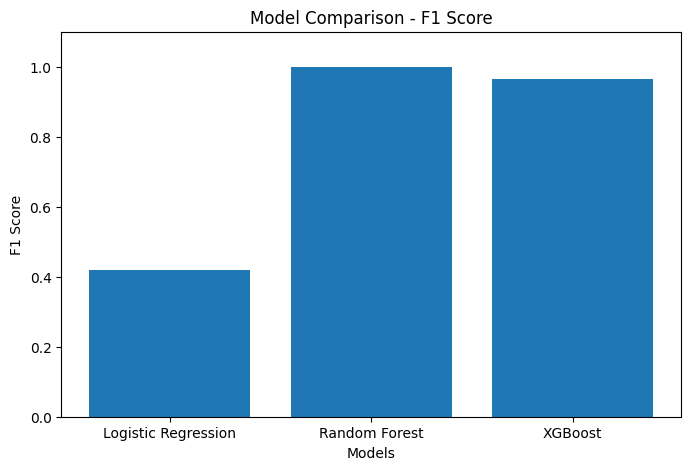

In [126]:
import matplotlib.pyplot as plt

# Model performance values
models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]

f1_scores = [
    0.419580,
    1.000000,
    0.965517
]

plt.figure(figsize=(8, 5))

plt.bar(models, f1_scores)

plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.title('Model Comparison - F1 Score')
plt.ylim(0, 1.1)

plt.show()

In [110]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get fraud probabilities from the tuned Random Forest
y_prob_tuned = best_rf.predict_proba(X_test_scaled_no_id)[:, 1]

thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)

    precision = precision_score(y_test_no_id, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test_no_id, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test_no_id, y_pred_threshold, zero_division=0)

    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=['Threshold', 'Precision', 'Recall', 'F1 Score']
)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.145631,1.000000,0.254237
1,0.15,0.206897,1.000000,0.342857
2,0.20,0.306122,1.000000,0.468750
3,0.25,0.508475,1.000000,0.674157
4,0.30,0.681818,1.000000,0.810811
5,0.35,0.878788,0.966667,0.920635
6,0.40,1.000000,0.933333,0.965517
7,0.45,1.000000,0.933333,0.965517
8,0.50,1.000000,0.933333,0.965517


In [111]:
# Final tuned Random Forest
final_model = best_rf

# Final fraud detection threshold
final_threshold = 0.40

print("Final Model: Tuned Random Forest")
print("Final Threshold:", final_threshold)

Final Model: Tuned Random Forest
Final Threshold: 0.4


In [112]:
import pickle

# Save the final tuned Random Forest model
with open('fraud_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

# Save the encoder
with open('encoder.pkl', 'wb') as file:
    pickle.dump(encoder_no_id, file)

# Save the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler_no_id, file)

print("All files saved successfully!")

All files saved successfully!


In [113]:
import os

print("fraud_model.pkl:", os.path.exists("fraud_model.pkl"))
print("encoder.pkl:", os.path.exists("encoder.pkl"))
print("scaler.pkl:", os.path.exists("scaler.pkl"))

fraud_model.pkl: True
encoder.pkl: True
scaler.pkl: True


In [116]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('encoder.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>